# Del 1


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import ipywidgets as widgets
from IPython.display import display

In [2]:
#Oppgave 1. Plan for kode var en som kunne hente inn data fra en excel fil i jupyter hub. Etter gjentatte forsøk for å 
#lage en slik kode endte jeg med en tabell som hadde data over svært få kategorier, men allikevel kunne være nyttig å se.
#Tabellen i excel format viser utviklingen av befolkningen i Norge noe som er ganske generelt. Den måler det så opp mot 
#antall fødte og døde. Befolkningen fortsetter å øke men fødetallene er betydelig lavere enn der de var. Det

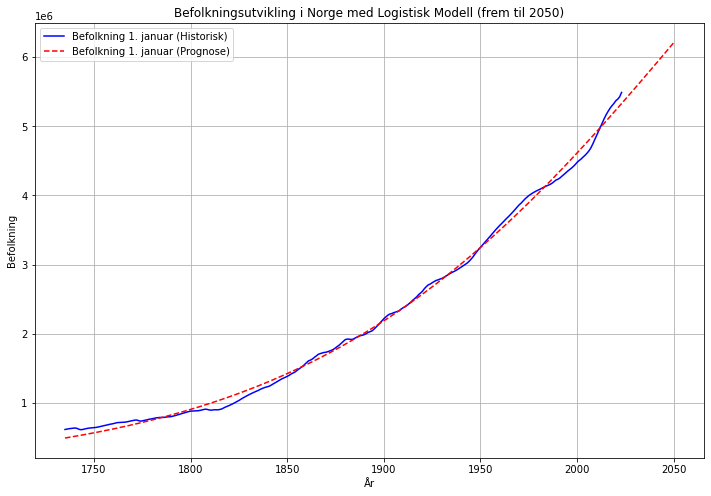

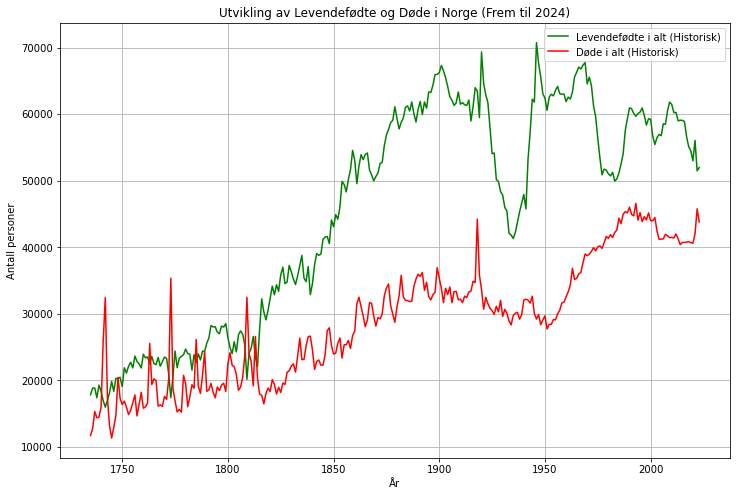

In [63]:
# Definerer logistisk vekstfunksjon
def logistisk_vekst(t, P0, K, r):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

# Last opp Excel-filen
filsti = "NorgeBefolkning1.xlsx"
data = pd.read_excel(filsti, engine='openpyxl')


# Navngi kolonnene på nytt
data.columns = ["Årstall", "Befolkning 1. januar", "Levendefødte i alt", "Døde i alt"]

# Konverter til numeriske verdier
data["Befolkning 1. januar"] = pd.to_numeric(data["Befolkning 1. januar"], errors='coerce')
data["Levendefødte i alt"] = pd.to_numeric(data["Levendefødte i alt"], errors='coerce')
data["Døde i alt"] = pd.to_numeric(data["Døde i alt"], errors='coerce')
data_renset = data.dropna()

# Definer tidr (årstall) og populasjon
t = np.array(data_renset['Årstall'])
populasjon = np.array(data_renset['Befolkning 1. januar'])
levendefødte = np.array(data_renset['Levendefødte i alt'])
døde = np.array(data_renset['Døde i alt'])

# Logistisk modell for antatt befolkningsvekst
P0 = populasjon[0]
K = 10_000_000  # Bæreevne
r = 0.02  # Vekstrate
params, _ = curve_fit(logistisk_vekst, t - t[0], populasjon, p0=[P0, K, r])
P0_fit, K_fit, r_fit = params

# Prognose for befolkning frem til 2050
fremtidige_år = np.arange(t[-1] + 1, 2051)
t_fremtid = np.concatenate((t, fremtidige_år))

# Logistisk prognose for befolkning
populasjon_prognose = logistisk_vekst(t_fremtid - t[0], P0_fit, K_fit, r_fit)

#Plot av befolkning
plt.figure(figsize=(12, 8))

# Plot for data hentet fra excel filen
plt.plot(t, populasjon, label='Befolkning 1. januar (Historisk)', color='blue')

# Plot for antatt vekst basert på excel filen
plt.plot(t_fremtid, populasjon_prognose, '--', label='Befolkning 1. januar (Prognose)', color='red')

# aksetitler
plt.xlabel('År')
plt.ylabel('Befolkning')
plt.title('Befolkningsutvikling i Norge med Logistisk Modell (frem til 2050)')
plt.legend()
plt.grid(True)
plt.show()

#Plot fødsler og døde
plt.figure(figsize=(12, 8))

# Historiske data for levendefødte og døde
plt.plot(t, levendefødte, label='Levendefødte i alt (Historisk)', color='green')
plt.plot(t, døde, label='Døde i alt (Historisk)', color='red')

# Aksetitler
plt.xlabel('År')
plt.ylabel('Antall personer')
plt.title('Utvikling av Levendefødte og Døde i Norge (Frem til 2024)')
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
#Oppgave 2 Sparekalkulatoren samler inn opplysninger fra kunden om ønsket månedlig innskudd og hva banken har gitt som rente. 
#Med en gitt tidsperiode regner koden ut hva forventet gevinst vil være opp mot inflasjon når tidsperioden er over. 
#En markør viser når målet er oppnådd. mulige forbedringer er å legge inn inflasjon fra før og gjøre renten mer flytende

Hvor mye vil du spare hver måned: 900
Hva er den årlige renten (i prosent): 6
over hvor mange år vil du spare: 7
Hva er den årlige inflasjonen (i prosent): 5
Hvor mye ønsker du å ha spart ved slutten av perioden: 900000
Du oppnådde ikke målet ditt på 900000.0 NOK. Du klarer 93666.53 NOK ved slutten av perioden.


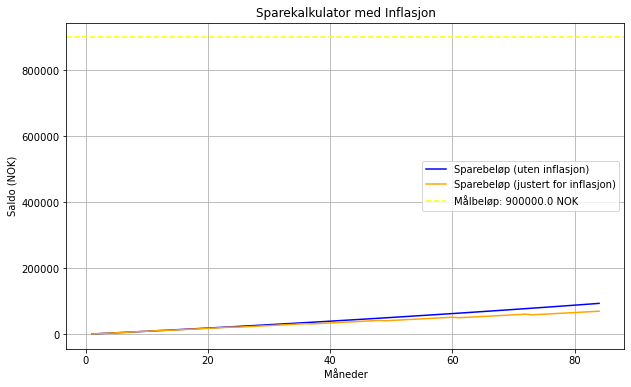

In [6]:

# Parametre fra bruker
def hent_terminbelop():
    sparesaldo = float(input("Hvor mye vil du spare hver måned: "))
    rente = float(input("Hva er den årlige renten (i prosent): "))
    tid = int(input("over hvor mange år vil du spare: "))
    inflasjon = float(input("Hva er den årlige inflasjonen (i prosent): "))
    return sparesaldo, rente, tid, inflasjon

# Sjekker om terminbeløpet er innenfor
def sjekk_terminbelop(sparesaldo):
    if sparesaldo <= 0:
        print("Ønsket beløp må være større enn 0.")
        return False
    return True

# Beregner sparebeløp over tid med renters rente og inflasjon
def beregn_sparebelop(sparesaldo, rente, tid, inflasjon):
    rentesats = rente / 100 / 12  # Månedlig rentesats
    inflasjonssats = inflasjon / 100  # Inflasjon per år
    måneder = tid * 12
    total_saldo = np.zeros(måneder)
    justert_saldo = np.zeros(måneder)  # Saldo justert for inflasjon

    for mnd in range(1, måneder+1):
        if mnd == 1:
            total_saldo[mnd-1] = sparesaldo
        else:
            total_saldo[mnd-1] = total_saldo[mnd-2] * (1 + rentesats) + sparesaldo
        
        # Juster saldo for inflasjon
        år = (mnd - 1) // 12
        justert_saldo[mnd-1] = total_saldo[mnd-1] / ((1 + inflasjonssats) ** år)
    
    return total_saldo, justert_saldo

# Sjekker om spareperioden er lang nok til å nå målet
def sjekk_nedbetalingstid(sparebelop, målbeløp):
    if sparebelop[-1] >= målbeløp:
        print(f"Kult! Du oppnår ønsket mål på {målbeløp} NOK i løpet av perioden.")
    else:
        print(f"Du oppnådde ikke målet ditt på {målbeløp} NOK. Du klarer {sparebelop[-1]:.2f} NOK ved slutten av perioden.")

# Finner når saldoen oppnår ønsket målbeløp (y-verdien)
def finn_skjaerpunkt(total_saldo, målbeløp):
    for i, saldo in enumerate(total_saldo):
        if saldo >= målbeløp:
            return i, saldo
    return None, None

# Resultatet med inflasjon
def vis_resultat(total_saldo, justert_saldo, tid, målbeløp):
    måneder = tid * 12
    plt.figure(figsize=(10, 6))
    
    # Graf for sparebeløpet over tid
    plt.plot(range(1, måneder+1), total_saldo, label="Sparebeløp (uten inflasjon)", color="blue")
    plt.plot(range(1, måneder+1), justert_saldo, label="Sparebeløp (justert for inflasjon)", color="orange")
    
    # Legg til ønsket beløp som horisontal linje
    plt.axhline(y=målbeløp, color='yellow', linestyle='--', label=f'Målbeløp: {målbeløp} NOK')
    
    # Finne skjæringspunktet mellom faktisk og ønsket verdi
    måned, skjaeringssaldo = finn_skjaerpunkt(total_saldo, målbeløp)
    
    if måned is not None:
        # Markør der grafen skjærer målbeløpet
        plt.plot(måned + 1, skjaeringssaldo, 'ro')  # Legg til en markør (rød prikk)
        plt.text(måned + 1, skjaeringssaldo, f'Skjæring: {skjaeringssaldo:.2f} NOK\nMåned: {måned + 1}', 
                 horizontalalignment='left', verticalalignment='bottom')

    # Overskrifter
    plt.xlabel("Måneder")
    plt.ylabel("Saldo (NOK)")
    plt.title("Sparekalkulator med Inflasjon")
    plt.legend()
    plt.grid(True)
    plt.show()

# Klargjør kalkulator med inflasjon
def run():
    sparesaldo, rente, tid, inflasjon = hent_terminbelop()

    if not sjekk_terminbelop(sparesaldo):
        return

    total_saldo, justert_saldo = beregn_sparebelop(sparesaldo, rente, tid, inflasjon)
    
    målbeløp = float(input("Hvor mye ønsker du å ha spart ved slutten av perioden: "))
    sjekk_nedbetalingstid(total_saldo, målbeløp)

    vis_resultat(total_saldo, justert_saldo, tid, målbeløp)

# Kjører kalkulatoren
run()


In [ ]:
Oppgave 4. En kundemasse på 2000 kunder etableres med tilhørende utdanninger

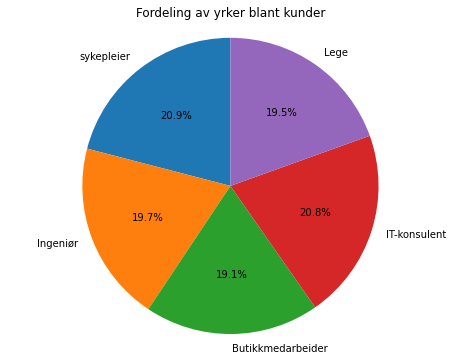

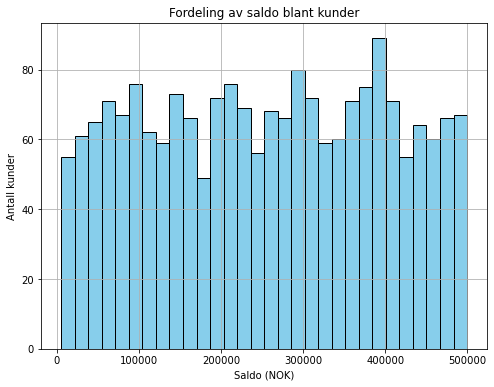

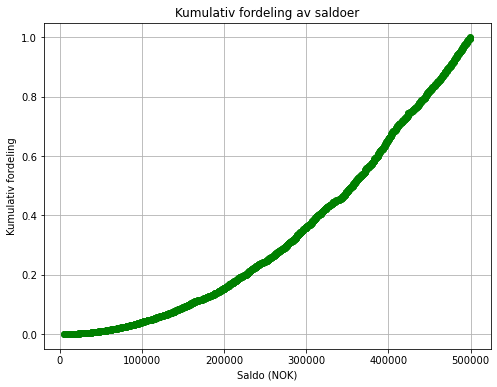

Statistiske nøkkeltall for saldo:
 - Gjennomsnitt: 254897.46 NOK
 - Varians: 19935932544.29
 - Standardavvik: 141194.66

Statistiske nøkkeltall for inntekt:
 - Gjennomsnitt: 758191.38 NOK
 - Varians: 66543546439.98
 - Standardavvik: 257960.36

Antall kunder med saldo over 200 000 NOK: 1239


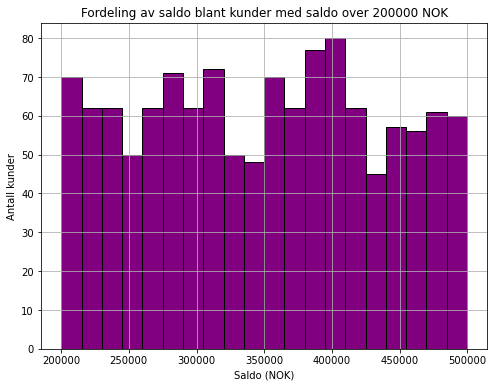

Gjennomsnittlig saldo for Master: 258899.84 NOK
Gjennomsnittlig saldo for Bachelor i fornybar energi: 247600.73 NOK
Gjennomsnittlig saldo for Vidregående: 251899.59 NOK
Gjennomsnittlig saldo for doktorgrad: 261769.55 NOK


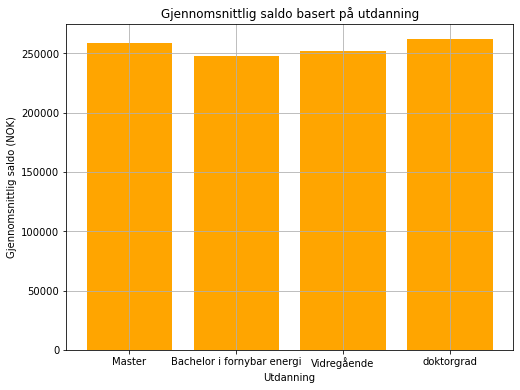

In [64]:
# Dataset med 2000 personer
def generer_kunder(n_kunder=2000):
    yrker = ["Ingeniør", "Lege", "sykepleier", "Butikkmedarbeider", "IT-konsulent"]
    utdanning = ["Master", "doktorgrad", "Bachelor i fornybar energi", "Vidregående"]
    kunder = []

    for _ in range(n_kunder):
        kunde = {
            "KundeID": random.randint(1000, 9999),
            "Yrke": random.choice(yrker),
            "Utdanning": random.choice(utdanning),
            "Saldo": round(random.uniform(5000, 500000), 2),  # Tilfeldig saldo mellom 5000 og 500000 NOK
            "Inntekt": round(random.uniform(300000, 1200000), 2)  # Tilfeldig årlig inntekt mellom 300k og 1.2 mill NOK
        }
        kunder.append(kunde)
    
    return kunder

kunder = generer_kunder()

# Filtrere kunder etter yrke
def filtrer_kunder_etter_yrke(kunder, yrke):
    return [kunde for kunde in kunder if kunde["Yrke"] == yrke]

# Funksjon for å filtrere kunder etter utdanning
def filtrer_kunder_etter_utdanning(kunder, utdanning):
    return [kunde for kunde in kunder if kunde["Utdanning"] == utdanning]

# Funksjon for å plotte kakediagram over fordelingen av yrker
def plot_yrkesfordeling(kunder):
    yrke_telling = defaultdict(int)
    for kunde in kunder:
        yrke_telling[kunde["Yrke"]] += 1

    yrker = list(yrke_telling.keys())
    teller = list(yrke_telling.values())
    
    plt.figure(figsize=(8, 6))
    plt.pie(teller, labels=yrker, autopct='%1.1f%%', startangle=90)
    plt.title('Fordeling av yrker blant kunder')
    plt.axis('equal')  # Sørger for at kaken er rund
    plt.show()

# Funksjon for å plotte histogram over saldoer
def plot_saldo_histogram(kunder):
    saldoer = [kunde["Saldo"] for kunde in kunder]
    
    plt.figure(figsize=(8, 6))
    plt.hist(saldoer, bins=30, color='skyblue', edgecolor='black')
    plt.title('Fordeling av saldo blant kunder')
    plt.xlabel('Saldo (NOK)')
    plt.ylabel('Antall kunder')
    plt.grid(True)
    plt.show()

# Funksjon for å plotte kumulativ fordeling av saldo
def plot_kumulativ_fordeling(kunder):
    saldoer = sorted([kunde["Saldo"] for kunde in kunder])
    kumulativ_fordeling = np.cumsum(saldoer) / np.sum(saldoer)
    
    plt.figure(figsize=(8, 6))
    plt.plot(saldoer, kumulativ_fordeling, color='green', marker='o')
    plt.title('Kumulativ fordeling av saldoer')
    plt.xlabel('Saldo (NOK)')
    plt.ylabel('Kumulativ fordeling')
    plt.grid(True)
    plt.show()
    
# Funksjon for å filtrere kunder med saldo over en viss grense
def filtrer_kunder_etter_saldo(kunder, grense):
    """
    Returnerer kunder som har en saldo høyere enn gitt grense.
    """
    return [kunde for kunde in kunder if kunde["Saldo"] > grense]
        
# Funksjon for å sammenligne saldo basert på utdanning
def sammenligne_saldo_basert_på_utdanning(kunder):
    utdanning_saldo = defaultdict(list)
    for kunde in kunder:
        utdanning_saldo[kunde["Utdanning"]].append(kunde["Saldo"])
    
    for utdanning, saldoer in utdanning_saldo.items():
        gjennomsnitt_saldo = np.mean(saldoer)
        print(f"Gjennomsnittlig saldo for {utdanning}: {gjennomsnitt_saldo:.2f} NOK")    
    
# Plotte histogram av kunder med høy saldo
def plot_hoy_saldo_histogram(kunder, grense):
    hoy_saldo_kunder = filtrer_kunder_etter_saldo(kunder, grense)
    saldoer = [kunde["Saldo"] for kunde in hoy_saldo_kunder]

    plt.figure(figsize=(8, 6))
    plt.hist(saldoer, bins=20, color='purple', edgecolor='black')
    plt.title(f'Fordeling av saldo blant kunder med saldo over {grense} NOK')
    plt.xlabel('Saldo (NOK)')
    plt.ylabel('Antall kunder')
    plt.grid(True)
    plt.show()
    
# Funksjon for å plotte gjennomsnittssaldo per utdanning
def plot_gjennomsnitt_saldo_utdanning(kunder):
    utdanning_saldo = defaultdict(list)
    for kunde in kunder:
        utdanning_saldo[kunde["Utdanning"]].append(kunde["Saldo"])
    
    utdanning = list(utdanning_saldo.keys())
    gjennomsnitt_saldo = [np.mean(saldoer) for saldoer in utdanning_saldo.values()]

    plt.figure(figsize=(8, 6))
    plt.bar(utdanning, gjennomsnitt_saldo, color='orange')
    plt.title('Gjennomsnittlig saldo basert på utdanning')
    plt.xlabel('Utdanning')
    plt.ylabel('Gjennomsnittlig saldo (NOK)')
    plt.grid(True)
    plt.show()

# Funksjon for å vise statistiske nøkkeltall for saldo og inntekt
def vis_statistiske_nokkeldata(kunder):
    saldoer = [kunde["Saldo"] for kunde in kunder]
    inntekter = [kunde["Inntekt"] for kunde in kunder]

    # Beregner gjennomsnitt, varians, og standardavvik for saldo og inntekt
    gjennomsnitt_saldo = np.mean(saldoer)
    varians_saldo = np.var(saldoer)
    std_saldo = np.std(saldoer)

    gjennomsnitt_inntekt = np.mean(inntekter)
    varians_inntekt = np.var(inntekter)
    std_inntekt = np.std(inntekter)

    print(f"Statistiske nøkkeltall for saldo:")
    print(f" - Gjennomsnitt: {gjennomsnitt_saldo:.2f} NOK")
    print(f" - Varians: {varians_saldo:.2f}")
    print(f" - Standardavvik: {std_saldo:.2f}\n")
    
    print(f"Statistiske nøkkeltall for inntekt:")
    print(f" - Gjennomsnitt: {gjennomsnitt_inntekt:.2f} NOK")
    print(f" - Varians: {varians_inntekt:.2f}")
    print(f" - Standardavvik: {std_inntekt:.2f}\n")

# Kjører hele oppgaven
def run():
    kunder = generer_kunder()

    # Plot yrkesfordeling
    plot_yrkesfordeling(kunder)
    
    # Plot saldo-histogram
    plot_saldo_histogram(kunder)
    
    # Plot kumulativ fordeling av saldo
    plot_kumulativ_fordeling(kunder)
    
    # Vis statistiske nøkkeltall
    vis_statistiske_nokkeldata(kunder)
    
    # Vis kunder med saldo over 200 000 NOK
    hoy_saldo_kunder = filtrer_kunder_etter_saldo(kunder, 200000)
    print(f"Antall kunder med saldo over 200 000 NOK: {len(hoy_saldo_kunder)}")

    # Plot histogram for kunder med høy saldo
    plot_hoy_saldo_histogram(kunder, 200000)
    
    # Sammenlign saldo basert på utdanning
    sammenligne_saldo_basert_på_utdanning(kunder)
    
    # Plot gjennomsnittlig saldo per utdanning
    plot_gjennomsnitt_saldo_utdanning(kunder)
    

# Kjører programmet
run()


In [ ]:
oppgave 5. Her var ambisjonen høy og øsnket om å lage en glider tok overhånd. Ideen her var en glider som når
justert, skulle endre vise en rød dot på grafen som beveget seg med grafen. Dette skulle tydeligjøre overskuddet

FloatSlider(value=50.0, description='Pris', max=150.0, min=50.0)

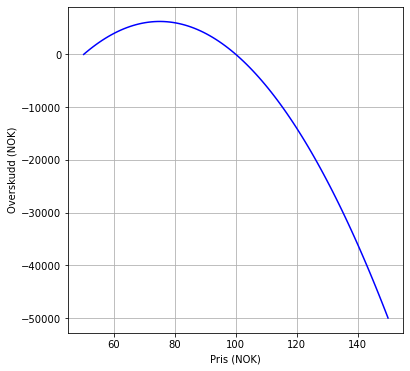

In [33]:
# Beregner overskudd
def overskudd(pris, innkjøpspris):
    a = 1000  # Etterspørsel
    b = 10    # Prisfølsomhet
    mengde_solgt = a - b * pris
    return (pris - innkjøpspris) * mengde_solgt

# Oppdaterer grafen basert på pris
def oppdater_graf(pris):
    overskudd_value = overskudd(pris, innkjøpspris)
    line.set_data([pris], [overskudd_value])
    ax.set_title(f'Overskudd ved pris: {pris:.2f} NOK')
    fig.canvas.draw_idle()

# Oppretter glideknapp til justere prisen
innkjøpspris = 50
pris_slider = widgets.FloatSlider(min=innkjøpspris, max=150, step=0.1, value=innkjøpspris, description='Pris')

# figuren og overskudd
fig, ax = plt.subplots(figsize=(6, 6))
priser = np.linspace(innkjøpspris, 150, 100)
overskudd_nivåer = [overskudd(p, innkjøpspris) for p in priser]
ax.plot(priser, overskudd_nivåer, label='Overskudd som funksjon av pris', color='blue')
line, = ax.plot([], [], 'ro', markersize=12)

# akseetiketter 
ax.set_xlabel('Pris (NOK)')
ax.set_ylabel('Overskudd (NOK)')
ax.grid(True)

# Koble glideknappen til grafoppdateringsfunksjonen
widgets.interactive(oppdater_graf, pris=pris_slider)

# Vis glideknappen og grafen
display(pris_slider)
plt.show()